In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch

from dvfm.data import sample_moons
from dvfm.flow_matching import flow_matching_loss
from dvfm.models import MLP

torch.manual_seed(0)

data = sample_moons(50_000, seed=0)
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [2]:
batch_size = 512
num_steps = 5000
losses = []

for step in range(num_steps):
    # Random batch of real data
    idx = torch.randint(0, len(data), (batch_size,))
    x1 = data[idx]

    # Compute loss and update the network
    loss = flow_matching_loss(model, x1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:5d} | loss {loss.item():.4f}")

step     0 | loss 1.9288
step   500 | loss 1.4137
step  1000 | loss 1.3755
step  1500 | loss 1.4553
step  2000 | loss 1.4140
step  2500 | loss 1.5083
step  3000 | loss 1.4454
step  3500 | loss 1.4797
step  4000 | loss 1.6130
step  4500 | loss 1.4810


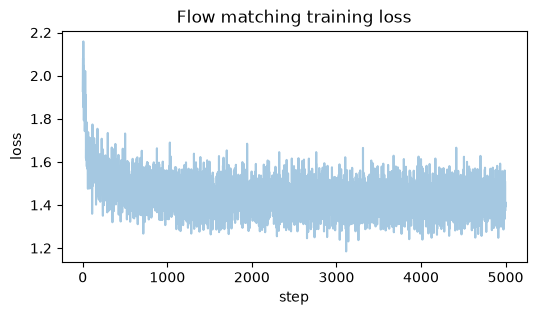

In [3]:
plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.4)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Flow matching training loss")
plt.show()

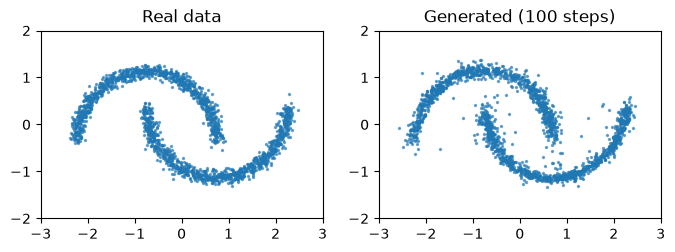

In [4]:
from dvfm.flow_matching import sample

model.eval()
generated = sample(model, 2000, num_steps=100)
real = data[torch.randperm(len(data))[:2000]]  # 2000 random real points

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, points, title in [(axes[0], real, "Real data"), (axes[1], generated, "Generated (100 steps)")]:
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)
plt.show()

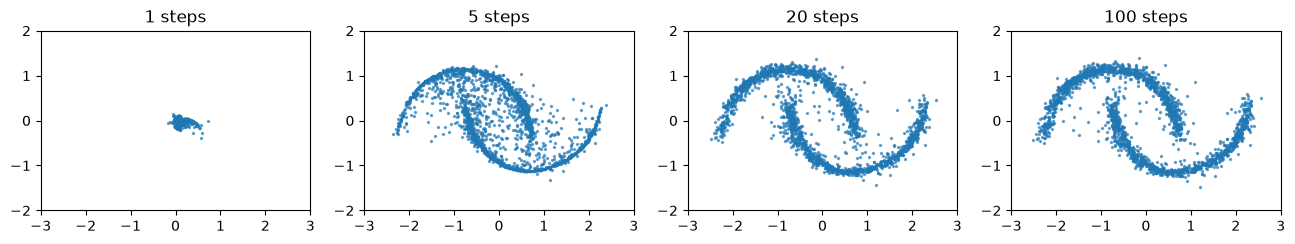

In [5]:
from pathlib import Path

steps_list = [1, 5, 20, 100]

fig, axes = plt.subplots(1, len(steps_list), figsize=(16, 4))
for ax, steps in zip(axes, steps_list):
    torch.manual_seed(0)  # same starting noise for every run, for a fair comparison
    points = sample(model, 2000, num_steps=steps)
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
    ax.set_title(f"{steps} steps")
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)

Path("../assets").mkdir(exist_ok=True)  # create the assets folder if it doesn't exist
plt.savefig("../assets/fm_steps_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
from matplotlib.animation import FuncAnimation, PillowWriter

torch.manual_seed(0)
generated, trajectory = sample(model, 2000, num_steps=100, return_trajectory=True)

# Repeat the last frame so the GIF pauses on the final result
frames = trajectory + [trajectory[-1]] * 20

fig, ax = plt.subplots(figsize=(5, 5))
scat = ax.scatter(frames[0][:, 0], frames[0][:, 1], s=2, alpha=0.6)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title("t = 0.00")


def update(i):
    scat.set_offsets(frames[i].numpy())  # move the points to frame i
    t = min(i, len(trajectory) - 1) / (len(trajectory) - 1)
    title.set_text(f"t = {t:.2f}")
    return scat, title


anim = FuncAnimation(fig, update, frames=len(frames), interval=50)
anim.save("../assets/fm_moons.gif", writer=PillowWriter(fps=20))
plt.close(fig)

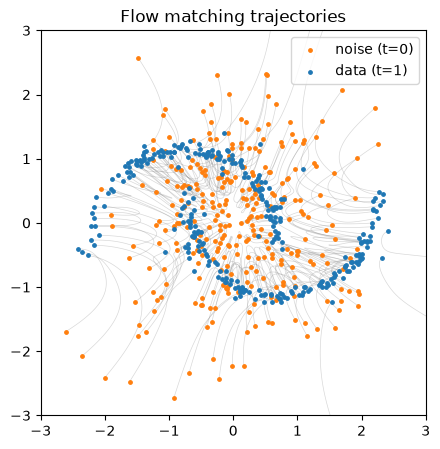

In [7]:
paths = torch.stack(trajectory)  # (num_steps + 1, n, 2)
k = 300  # draw only 300 paths so the figure is readable

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(paths[:, :k, 0], paths[:, :k, 1], lw=0.5, alpha=0.3, color="gray")
ax.scatter(paths[0, :k, 0], paths[0, :k, 1], s=6, color="tab:orange", label="noise (t=0)", zorder=3)
ax.scatter(paths[-1, :k, 0], paths[-1, :k, 1], s=6, color="tab:blue", label="data (t=1)", zorder=3)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_title("Flow matching trajectories")

plt.savefig("../assets/fm_moons_paths.png", dpi=150, bbox_inches="tight")
plt.show()